# Project 1: The AR (Auto-Regressive) Model
### **Scenario:** Predicting daily "Internal Temperature" of a server room.
#### Why AR? Temperature doesn't jump randomly; it is heavily "anchored" to what it was 10 minutes ago.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# 1. Create Data (Strongly related to its own past)
df_ar = pd.read_csv(r"C:\Users\niles\Downloads\AR Data.csv")
df_ar

,Temp
0,25.000000
1,17.748357
2,12.354718
3,8.972147
4,7.042018
...,...
95,-0.273247
96,-0.923031
97,-0.498061
98,-0.218115


In [3]:
# 2. Identify Stationarity (Step 1)
result = adfuller(df_ar['Temp'])
print(f"ADF P-value: {result[1]}") # Should be < 0.05 (Stationary, so d=0)

ADF P-value: 0.0


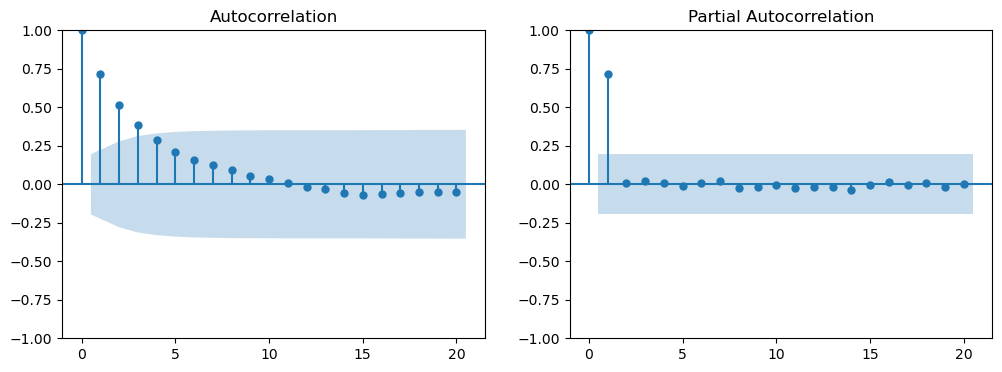

In [4]:
# 3. Diagnostics: Why AR? (Step 2)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df_ar['Temp'], ax=ax[0])   # Will tail off slowly
plot_pacf(df_ar['Temp'], ax=ax[1])  # Will shut off after Lag 1
plt.show()

In [5]:
# POINT: PACF cuts off at 1, ACF tails off -> This is AR(1)
# 4. Fit AR Model
model_ar = ARIMA(df_ar['Temp'], order=(1, 0, 0)) # (p=1, d=0, q=0)
res_ar = model_ar.fit()
print(res_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -157.303
Date:                Sat, 14 Mar 2026   AIC                            320.606
Time:                        08:50:56   BIC                            328.421
Sample:                             0   HQIC                           323.769
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.2598     12.522      0.819      0.413     -14.282      34.802
ar.L1          0.9955      0.018     55.919      0.000       0.961       1.030
sigma2         1.2983      0.092     14.169      0.0

##### Zone 1: The Fitness Score (Header Section)
This section tells us how well the model fits the data.

Model: ARIMA(1, 0, 0): This confirms we are using an AR(1) model.

No. Observations: 100: The size of our dataset.

#### AIC (Akaike Information Criterion): 320.606: *  Point: This is the most important "Competition Score." If we tried an ARIMA(2,0,0) and the AIC was 340, the current model (320) is better. 
#### Lower AIC = Better Model. It rewards accuracy but penalizes over-complicating the model.

##### Zone 2: The Model Ingredients (Middle Section)This is where we see the "weights" the model assigned to its logic.const 

**(Constant):** The "Average" value if no other factors were present.Look at $P>|z|$: It is 0.413. Since this is $> 0.05$, the constant is not statistically significant. The model could likely run without it.

**ar.L1 (The AR Coefficient): 0.9955** Point: This is huge! It means nearly 99.5% of yesterday's value carries over to today. It proves the data has very strong "memory" or momentum.Look at $P>|z|$: It is 0.000. This is $< 0.05$, so this lag is highly significant. Our choice of $p=1$ was correct.

**sigma2:** This represents the variance of the "Noise" (residuals).

### Zone 3: The Diagnostic Health Check (Bottom Section)This is the "High-End" knowledge. We check if the model's "leftover errors" (residuals) are truly random.

**Ljung-Box (L1) (Q):** Checks if there is any "pattern" left in the errors.

**Prob(Q) is 0.00:** In an ideal model, this should be $> 0.05$. Since it is 0.00, it suggests there is still some information in the data we haven't captured. The model isn't "perfectly clean" yet.

**Jarque-Bera (JB):** Checks if the errors are normally distributed (Bell Curve)

**Prob(JB) is 0.00:** This means our errors are not normally distributed.

**Skew (-3.62) & Kurtosis (20.76):** Point: Normal data has a Skew of 0 and Kurtosis of 3. Our Kurtosis is 20.76, which tells us the data has "Fat Tails"—meaning there were some extreme outliers or sudden spikes in the temperature that the model found hard to predict.

In [6]:
forecast_ar = res_ar.forecast(steps=5)
forecast_ar

100   -0.103323
101   -0.056733
102   -0.010352
103    0.035820
104    0.081785
Name: predicted_mean, dtype: float64

# Project 2: The MA (Moving Average) Model
#### **Scenario:** Modeling "Call Center Noise"—random spikes in calls that don't last.
#### Why MA? Today's volume isn't based on yesterday's total, but on a "shock" (like a marketing email sent yesterday).

In [7]:
# 1. Create Data (Dependent on past errors/shocks)

df_ma = pd.read_csv(r"C:\Users\niles\Downloads\MA Data.csv")
df_ma


,Calls
0,-0.234587
1,8.443877
2,8.730132
3,9.404898
4,8.992094
...,...
95,9.425738
96,10.489226
97,9.347333
98,9.623411


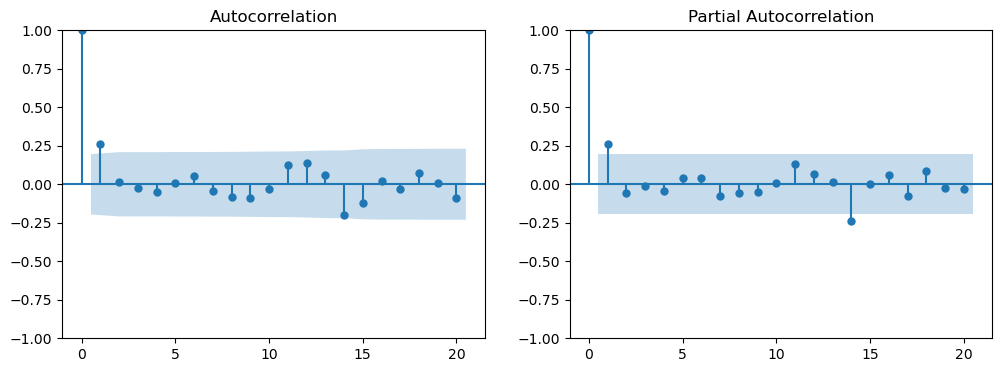

In [8]:
# 2. Diagnostics: Why MA?
fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df_ma['Calls'], ax=ax[0])   # Will shut off after Lag 1
plot_pacf(df_ma['Calls'], ax=ax[1])  # Will tail off slowly
plt.show()


In [9]:
# TEACHING POINT: ACF cuts off at 1, PACF tails off -> This is MA(1)
# 3. Fit MA Model
model_ma = ARIMA(df_ma['Calls'], order=(0, 0, 1)) # (p=0, d=0, q=1)
res_ma = model_ma.fit()

In [10]:
forecast_ar = res_ma.forecast(steps=5)
forecast_ar

100    9.975788
101    9.895032
102    9.895032
103    9.895032
104    9.895032
Name: predicted_mean, dtype: float64

# Project 3: The ARIMA Model (The Most Common)
#### **Scenario:** Monthly Revenue of a growing E-commerce store.
#### Why ARIMA? There is a Trend (needs $d$) and History (needs $p, q$).

In [11]:
# 1. Create Data with Trend

df_arima = pd.read_csv(r"C:\Users\niles\Downloads\ARIMA Data.csv")
df_arima

,Revenue
0,94.285149
1,102.799038
2,104.824125
3,108.445559
4,109.309414
...,...
95,197.744673
96,193.505149
97,202.477797
98,200.526397


In [12]:
# 2. Check Stationarity (Step 1)
result = adfuller(df_arima['Revenue'])
print(f"ADF P-value: {result[1]}") # Should be < 0.05 (Stationary, so d=0)

ADF P-value: 0.965725848416803


In [13]:
# 3. Make it stationary (Differencing)
stationary_rev = df_arima['Revenue'].diff().dropna()
# d=1 because we differenced once.


In [14]:
#  Check Stationarity (Step 1)
result = adfuller(stationary_rev)
print(f"ADF P-value: {result[1]}") # Should be < 0.05 (Stationary, so d=0)

ADF P-value: 6.107495764055003e-12


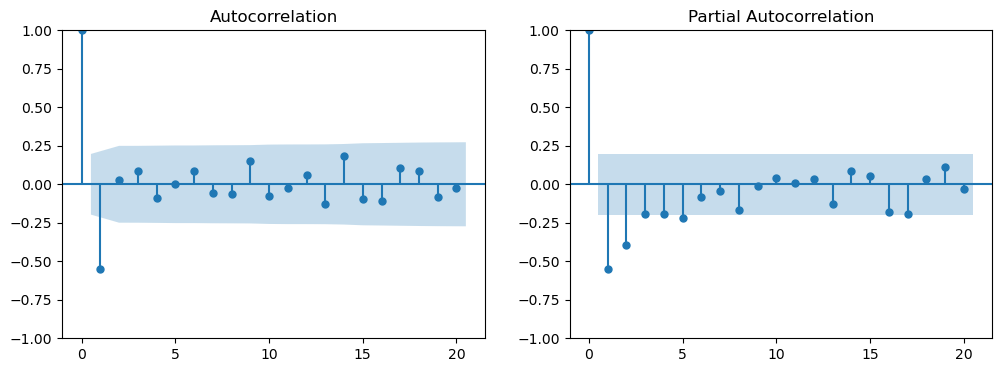

In [15]:
# 4. Diagnostics on the DIFFERENCED data
fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(stationary_rev, ax=ax[0])
plot_pacf(stationary_rev, ax=ax[1])
plt.show()


In [16]:
# 5. Fit ARIMA(p, 1, q)
# If PACF=1 and ACF=1 bars outside
model_arima = ARIMA(df_arima['Revenue'], order=(1, 1, 1))
res_arima = model_arima.fit()

# 6. Forecast 10 months
forecast = res_arima.forecast(steps=10)
print(forecast)

100    201.001948
101    201.760645
102    201.572679
103    201.619247
104    201.607710
105    201.610568
106    201.609860
107    201.610036
108    201.609992
109    201.610003
Name: predicted_mean, dtype: float64


# Project 4: The SARIMA Model
#### **Scenario:** Monthly Ice Cream Sales over 3 years.
#### Why SARIMA? There is a trend AND a repetitive pattern every 12 months.

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Create Seasonal Data (12 month cycle)
df_s = pd.read_csv(r"C:\Users\niles\Downloads\SARIMA Data.csv")
df_s


,Sales
0,51.259258
1,53.842010
2,58.539892
3,62.994587
4,61.880995
...,...
115,103.164628
116,97.842773
117,101.602304
118,100.571095


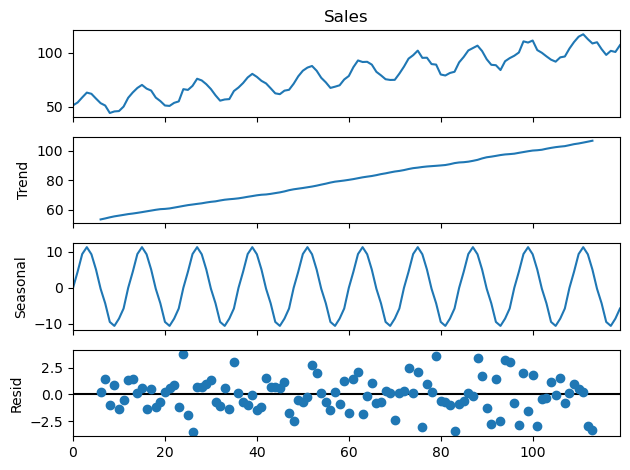

In [18]:
# 2. Identify Seasonality: Use a Seasonal Decompose Plot
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df_s['Sales'], period=12)
decomp.plot()
plt.show()

<Axes: >

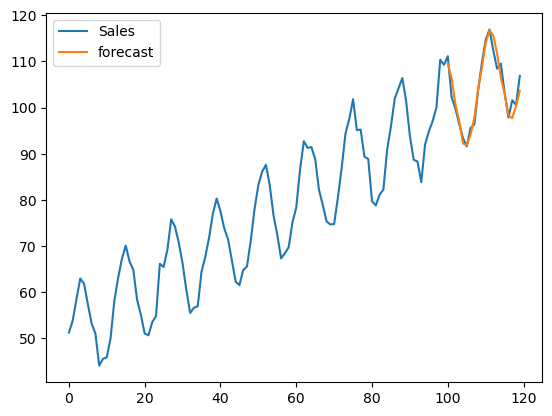

In [19]:
#  POINT: If the 'Seasonal' row shows a repeating wave, use SARIMA!

# 3. Fit SARIMA
# (p,d,q) for short term, (P,D,Q,s) for the 12-month wave
model_s = SARIMAX(df_s['Sales'], 
                  order=(1, 1, 1), 
                  seasonal_order=(1, 1, 1, 12))
res_s = model_s.fit()

# 4. Forecast and Plot
df_s['forecast'] = res_s.predict(start=100, end=119)
df_s[['Sales', 'forecast']].plot()